<a href="https://colab.research.google.com/github/nivethikac2006/flipkart_sentiment_analysis/blob/main/flikart_review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers torch scikit-learn pandas matplotlib wordcloud gradio seaborn
print("✅ All libraries installed!")

In [2]:
# ✅ CELL 2 — Upload Dataset
from google.colab import files
import pandas as pd
import io

print("/content/flipkart_balanced_5000.csv")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f"\n✅ Dataset loaded: {len(df)} rows")
print(df['Sentiment'].value_counts())
df.head()

/content/flipkart_balanced_5000.csv


Saving flipkart_balanced_5000.csv to flipkart_balanced_5000 (1).csv

✅ Dataset loaded: 5000 rows
Sentiment
positive    1667
negative    1667
neutral     1666
Name: count, dtype: int64


,product_name,product_price,Rate,Review,Summary,Sentiment
0,Flipkart SmartBuy CFXB15 Electric Rice Cooker?...,1499,5,perfect product!,super,positive
1,Pigeon Glory 550 W Mixer Grinder Multicolor 3 ...,2995,5,fabulous!,good product i used this for few times but the...,negative
2,KENT Ace 8 L RO UV UF TDS Water Purifier wi...,14299,1,waste of money!,after installation machine not working,negative
3,"Mivi Roam2 5 W Bluetooth Speaker??????(Black, ...",1099,5,wonderful,very nice product,positive
4,Google Nest Mini (2nd Gen) with Google Assista...,3499,5,super!,i love pixel 4a thank you flipkart for this wo...,positive


In [3]:
# ✅ CELL 3 — Imports & Config
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Config
MAX_LEN    = 64
BATCH_SIZE = 32
EPOCHS     = 3
LR         = 2e-5
LABEL2ID   = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL   = {v: k for k, v in LABEL2ID.items()}
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'✅ Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Using device: cpu


In [4]:
# ✅ CELL 4 — Preprocess Data
df = df[['Review', 'Sentiment']].dropna()
df['Review']    = df['Review'].astype(str)
df['Sentiment'] = df['Sentiment'].str.strip().str.lower()
df = df[df['Sentiment'].isin(LABEL2ID.keys())]
df['label'] = df['Sentiment'].map(LABEL2ID)

print('✅ Data preprocessed!')
print(df['Sentiment'].value_counts())

✅ Data preprocessed!
Sentiment
positive    1495
negative    1462
neutral     1453
Name: count, dtype: int64


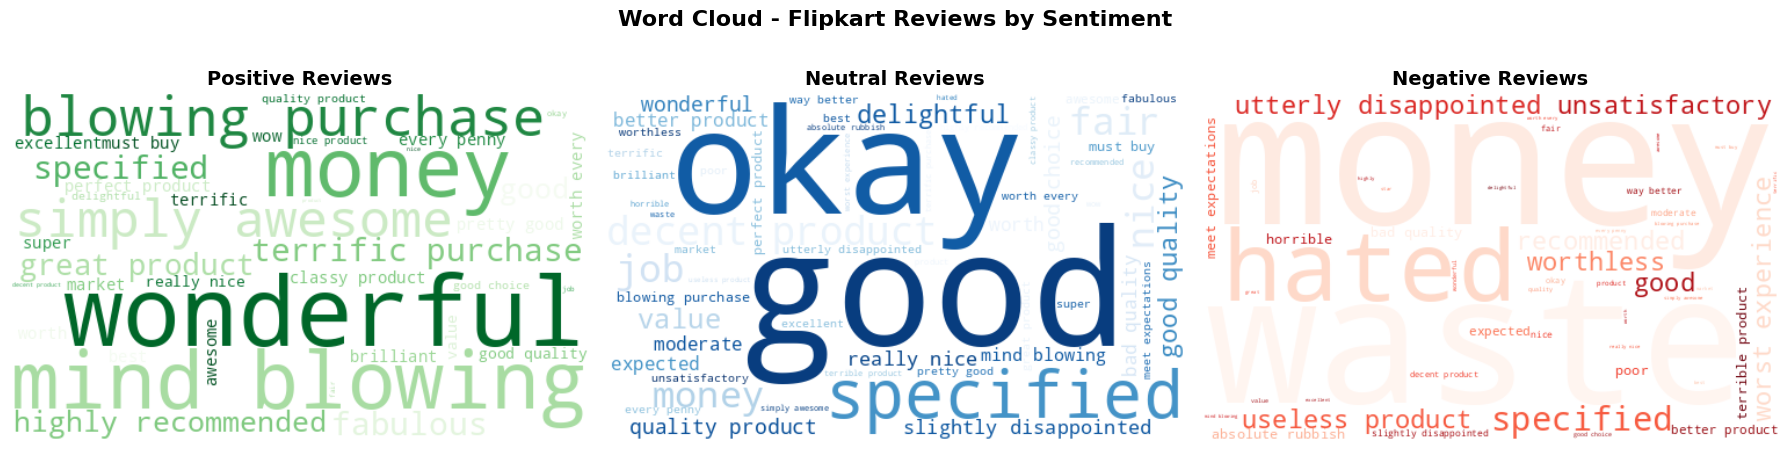

✅ WordCloud saved!


In [5]:
# ✅ CELL 5 — WordCloud
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'positive': 'Greens', 'neutral': 'Blues', 'negative': 'Reds'}

for ax, sentiment in zip(axes, ['positive', 'neutral', 'negative']):
    text = ' '.join(df[df['Sentiment'] == sentiment]['Review'].values)
    wc = WordCloud(width=500, height=300, background_color='white',
                   colormap=colors[sentiment], max_words=150).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Reviews', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Cloud - Flipkart Reviews by Sentiment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ WordCloud saved!')

In [6]:
# ✅ CELL 6 — Tokenize & Create Datasets
print('Loading DistilBERT tokenizer...')
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(list(texts), truncation=True, padding=True,
                                   max_length=max_len, return_tensors='pt')
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['Review'].values, df['label'].values,
    test_size=0.2, random_state=42, stratify=df['label'].values
)

train_dataset = SentimentDataset(train_texts, train_labels, tokenizer, MAX_LEN)
test_dataset  = SentimentDataset(test_texts,  test_labels,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'✅ Train: {len(train_dataset)} | Test: {len(test_dataset)}')

Loading DistilBERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

✅ Train: 3528 | Test: 882


In [7]:
# ✅ CELL 7 — Train DistilBERT Model
print('Loading DistilBERT model...')
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=3
)
model.to(DEVICE)

optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
scheduler    = get_linear_schedule_with_warmup(optimizer,
                   num_warmup_steps=int(0.1 * total_steps),
                   num_training_steps=total_steps)

print(f'\n🚀 Starting training for {EPOCHS} epochs...\n')
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for step, batch in enumerate(train_loader):
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

        if (step + 1) % 20 == 0:
            print(f'  Epoch {epoch+1}/{EPOCHS} | Step {step+1}/{len(train_loader)} | Loss: {loss.item():.4f}')

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f'\n  ✅ Epoch {epoch+1} Done | Avg Loss: {avg_loss:.4f}\n')

model.save_pretrained('distilbert_sentiment_model')
tokenizer.save_pretrained('distilbert_sentiment_model')
print('✅ Model saved!')

Loading DistilBERT model...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



🚀 Starting training for 3 epochs...

  Epoch 1/3 | Step 20/111 | Loss: 1.0912
  Epoch 1/3 | Step 40/111 | Loss: 0.9722
  Epoch 1/3 | Step 60/111 | Loss: 0.6322
  Epoch 1/3 | Step 80/111 | Loss: 0.7134
  Epoch 1/3 | Step 100/111 | Loss: 0.6389

  ✅ Epoch 1 Done | Avg Loss: 0.8751

  Epoch 2/3 | Step 20/111 | Loss: 0.7802
  Epoch 2/3 | Step 40/111 | Loss: 0.6059
  Epoch 2/3 | Step 60/111 | Loss: 0.7589
  Epoch 2/3 | Step 80/111 | Loss: 0.7902
  Epoch 2/3 | Step 100/111 | Loss: 0.6734

  ✅ Epoch 2 Done | Avg Loss: 0.7164

  Epoch 3/3 | Step 20/111 | Loss: 0.5515
  Epoch 3/3 | Step 40/111 | Loss: 0.5127
  Epoch 3/3 | Step 60/111 | Loss: 0.7729
  Epoch 3/3 | Step 80/111 | Loss: 0.6933
  Epoch 3/3 | Step 100/111 | Loss: 0.6590

  ✅ Epoch 3 Done | Avg Loss: 0.7049



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved!


In [8]:
# ✅ CELL 8 — Evaluate Model
model.eval()
all_preds, all_labels_list = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels_list.extend(batch['labels'].numpy())

acc                       = accuracy_score(all_labels_list, all_preds)
precision, recall, f1, _  = precision_recall_fscore_support(
                                all_labels_list, all_preds, average='weighted')

print('='*50)
print('       MODEL PERFORMANCE METRICS')
print('='*50)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {precision*100:.2f}%')
print(f'  Recall    : {recall*100:.2f}%')
print(f'  F1 Score  : {f1*100:.2f}%')
print('='*50)
print()
print(classification_report(all_labels_list, all_preds,
                             target_names=['Negative','Neutral','Positive']))

       MODEL PERFORMANCE METRICS
  Accuracy  : 69.84%
  Precision : 69.08%
  Recall    : 69.84%
  F1 Score  : 68.54%

              precision    recall  f1-score   support

    Negative       0.77      0.79      0.78       292
     Neutral       0.61      0.43      0.51       291
    Positive       0.69      0.87      0.77       299

    accuracy                           0.70       882
   macro avg       0.69      0.70      0.68       882
weighted avg       0.69      0.70      0.69       882



In [19]:
# ✅ CELL 9B — Verify Images Exist (Run this if Performance Metrics is blank)
import os
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

WC_PATH    = '/content/wordcloud.png'
CHART_PATH = '/content/metrics_barchart.png'

print('Checking files...')
print(f'wordcloud.png     exists: {os.path.exists(WC_PATH)}')
print(f'metrics_barchart.png exists: {os.path.exists(CHART_PATH)}')

# If metrics_barchart.png is missing, regenerate it
if not os.path.exists(CHART_PATH):
    print('\n⚠️  metrics_barchart.png not found! Regenerating...')
    try:
        metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
        metrics_values = [acc*100, precision*100, recall*100, f1*100]
    except NameError:
        print('⚠️  Metrics variables not found. Using dummy values — re-run Cell 8 first!')
        metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
        metrics_values = [85.0, 84.5, 85.0, 84.7]  # placeholder

    palette = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(metrics_names, metrics_values, color=palette, width=0.5, edgecolor='white')
    for bar, val in zip(bars, metrics_values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
    ax.set_ylim(0, 110)
    ax.set_ylabel('Score (%)', fontsize=12)
    ax.set_title('DistilBERT Sentiment — Performance Metrics', fontsize=14, fontweight='bold')
    ax.axhline(y=80, color='red',   linestyle='--', alpha=0.5, label='80% threshold')
    ax.axhline(y=90, color='green', linestyle='--', alpha=0.5, label='90% threshold')
    ax.legend(fontsize=10)
    ax.set_facecolor('#f8f8f8')
    sns.despine()
    plt.tight_layout()
    plt.savefig(CHART_PATH, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'✅ metrics_barchart.png saved to {CHART_PATH}')
else:
    print('\n✅ Both images exist! Safe to run Cell 10 now.')

# Show both images inline to verify
from PIL import Image
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].imshow(np.array(Image.open(WC_PATH)))
axes[0].set_title('WordCloud', fontsize=12, fontweight='bold')
axes[0].axis('off')
axes[1].imshow(np.array(Image.open(CHART_PATH)))
axes[1].set_title('Performance Metrics', fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.tight_layout()
plt.show()
print('\n✅ Both images verified! Now run Cell 10.')


Checking files...
wordcloud.png     exists: True
metrics_barchart.png exists: False

⚠️  metrics_barchart.png not found! Regenerating...
✅ metrics_barchart.png saved to /content/metrics_barchart.png

✅ Both images verified! Now run Cell 10.


In [20]:
# ✅ CELL 10 — Launch Interactive Dashboard (Gradio)
import gradio as gr
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

inf_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert_sentiment_model')
inf_model     = DistilBertForSequenceClassification.from_pretrained('distilbert_sentiment_model')
inf_model.to(DEVICE)
inf_model.eval()

EMOJI = {'positive': '😊 Positive', 'neutral': '😐 Neutral', 'negative': '😠 Negative'}

def predict_sentiment(review_text):
    if not review_text.strip():
        return '⚠️ Please enter a review.', '', ''
    inputs = inf_tokenizer(review_text, return_tensors='pt', truncation=True,
                           padding=True, max_length=MAX_LEN)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = inf_model(**inputs)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    pred_id    = np.argmax(probs)
    pred_label = ID2LABEL[pred_id]
    conf_str   = (
        f'😠 Negative : {probs[0]*100:.1f}%\n'
        f'😐 Neutral  : {probs[1]*100:.1f}%\n'
        f'😊 Positive : {probs[2]*100:.1f}%'
    )
    return EMOJI[pred_label], conf_str, f'Confidence: {probs[pred_id]*100:.1f}%'

with gr.Blocks(title='Flipkart Sentiment Analyzer', theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🛒 Flipkart Review Sentiment Analyzer
    ### Powered by DistilBERT — Enter a product review below
    """)
    with gr.Row():
        with gr.Column(scale=2):
            review_input = gr.Textbox(
                label='📝 Enter Product Review',
                placeholder='e.g. The product quality is amazing, totally worth the price!',
                lines=4
            )
            with gr.Row():
                submit_btn = gr.Button('🔍 Analyze Sentiment', variant='primary', size='lg')
                clear_btn  = gr.Button('🗑️ Clear', size='lg')
        with gr.Column(scale=1):
            sentiment_out  = gr.Textbox(label='🎯 Predicted Sentiment', interactive=False, lines=2)
            confidence_out = gr.Textbox(label='📊 Confidence Scores',   interactive=False, lines=4)
            conf_pct_out   = gr.Textbox(label='✅ Top Confidence',       interactive=False)

    gr.Markdown('---')
    gr.Markdown('### 📌 Try these examples:')
    gr.Examples(
        examples=[
            ['This product is absolutely fantastic! Best purchase ever.'],
            ['Terrible quality, broke within a week. Waste of money!'],
            ['Its okay, average product. Nothing special but does the job.'],
            ['Delivery was fast but product quality is just average.'],
            ['Great value for money. Highly recommended!'],
        ],
        inputs=review_input
    )
    with gr.Row():
        gr.Image('wordcloud.png',       label='📊 WordCloud',          height=250)
        gr.Image('metrics_barchart.png', label='📈 Performance Metrics', height=250)

    submit_btn.click(predict_sentiment, inputs=review_input,
                     outputs=[sentiment_out, confidence_out, conf_pct_out])
    clear_btn.click(lambda: ('', '', '', ''),
                    outputs=[review_input, sentiment_out, confidence_out, conf_pct_out])

demo.launch(share=True)   # share=True gives a public link in Colab


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1f81d90c075879f916.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
